# Ejemplo de análisis en Jupyter Notebook

Este notebook muestra cómo:

1. Crear y activar un ambiente virtual en Python.
2. Instalar Jupyter Notebook dentro del ambiente virtual.
3. Cargar un archivo CSV con ventas diarias de pan de una panadería.
4. Graficar la venta diaria en **kilogramos**.
5. Graficar la venta diaria en **dinero**.
6. Normalizar ambas variables y compararlas en un solo gráfico.

> Archivo esperado: `ventas_pan_diarias.csv`


## 1. Crear el ambiente virtual

Ejecuta estos comandos en tu terminal:

```bash
python -m venv .venv
```

### Activación

**Windows**
```bash
.venv\Scripts\activate
```

**Linux / macOS**
```bash
source .venv/bin/activate
```


## 2. Instalar Jupyter Notebook dentro del ambiente virtual

Con el ambiente virtual activado:

```bash
pip install jupyter pandas matplotlib
```

Luego inicia Jupyter Notebook con:

```bash
jupyter notebook
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Mostrar gráficos más grandes
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rfkv49w9 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## 3. Cargar el CSV

In [2]:
df = pd.read_csv("ventas_pan_diarias.csv", parse_dates=["fecha"])
df.head()

,fecha,venta_kg,venta_dinero
0,2025-01-01,112.48,415.05
1,2025-01-02,105.22,374.58
2,2025-01-03,115.20,408.96
3,2025-01-04,140.84,509.84
4,2025-01-05,125.09,456.58


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         365 non-null    datetime64[ns]
 1   venta_kg      365 non-null    float64       
 2   venta_dinero  365 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.7 KB


## 4. Gráfico de curva: venta diaria de pan en kilogramos

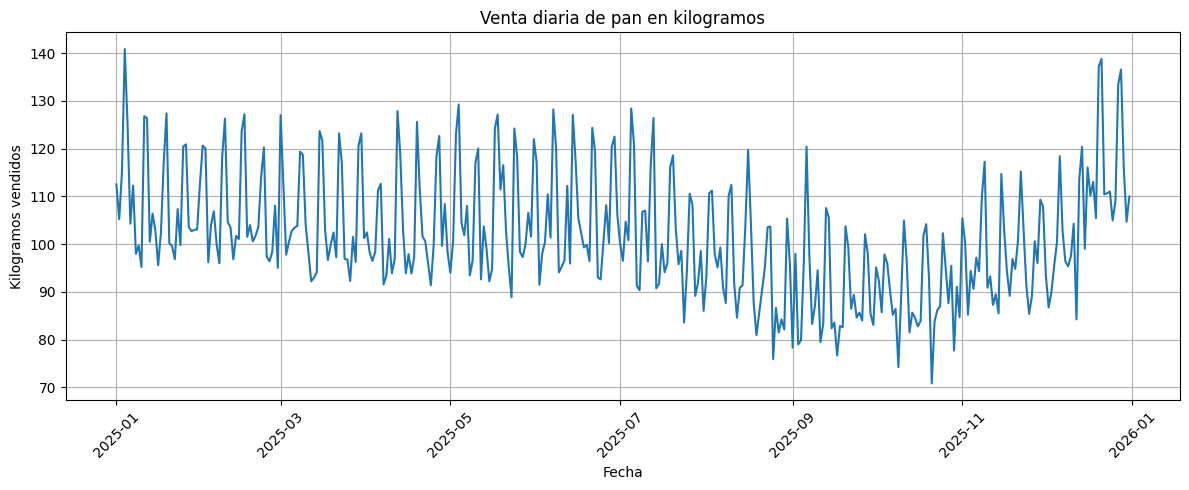

In [4]:
plt.figure()
plt.plot(df["fecha"], df["venta_kg"])
plt.title("Venta diaria de pan en kilogramos")
plt.xlabel("Fecha")
plt.ylabel("Kilogramos vendidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Gráfico de curva: venta diaria de pan en dinero

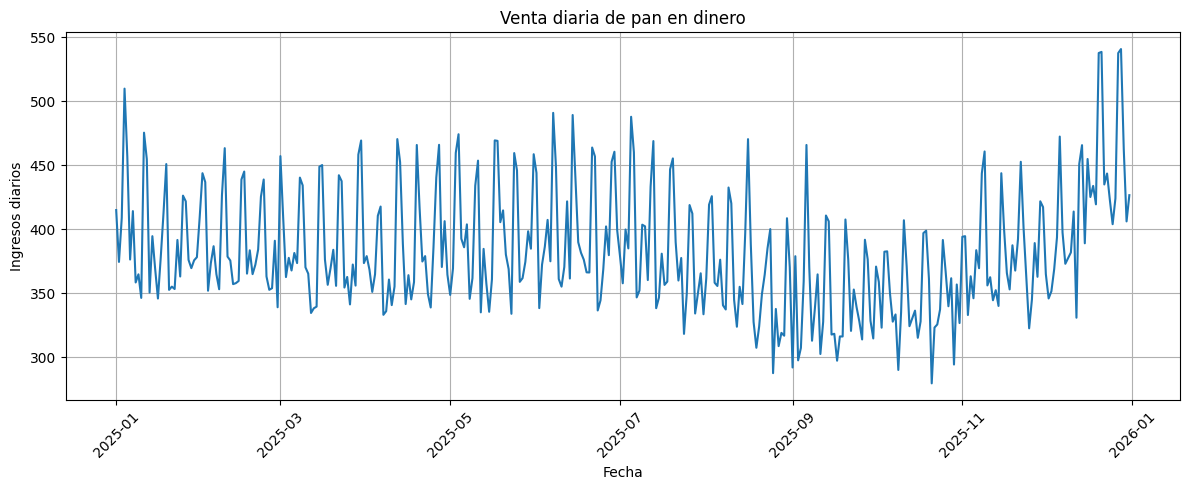

In [5]:
plt.figure()
plt.plot(df["fecha"], df["venta_dinero"])
plt.title("Venta diaria de pan en dinero")
plt.xlabel("Fecha")
plt.ylabel("Ingresos diarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Normalización de ventas en kg y dinero

In [6]:
df["venta_kg_normalizada"] = (
    (df["venta_kg"] - df["venta_kg"].min()) /
    (df["venta_kg"].max() - df["venta_kg"].min())
)

df["venta_dinero_normalizada"] = (
    (df["venta_dinero"] - df["venta_dinero"].min()) /
    (df["venta_dinero"].max() - df["venta_dinero"].min())
)

df[["fecha", "venta_kg_normalizada", "venta_dinero_normalizada"]].head()

,fecha,venta_kg_normalizada,venta_dinero_normalizada
0,2025-01-01,0.594915,0.518355
1,2025-01-02,0.491216,0.363274
2,2025-01-03,0.633767,0.495018
3,2025-01-04,1.000000,0.881591
4,2025-01-05,0.775032,0.677498


## 7. Gráfico combinado de las variables normalizadas

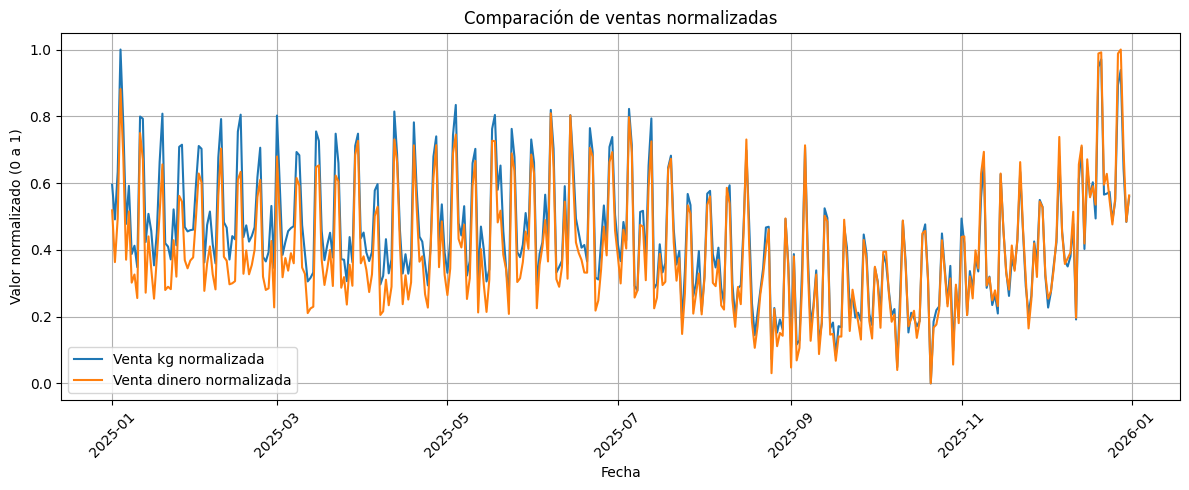

In [7]:
plt.figure()
plt.plot(df["fecha"], df["venta_kg_normalizada"], label="Venta kg normalizada")
plt.plot(df["fecha"], df["venta_dinero_normalizada"], label="Venta dinero normalizada")
plt.title("Comparación de ventas normalizadas")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado (0 a 1)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusión

Con este ejemplo ya tienes un flujo completo de trabajo:

- ambiente virtual,
- Jupyter Notebook instalado en ese ambiente,
- lectura de datos desde un CSV,
- dos gráficos de curvas independientes,
- y una comparación conjunta usando normalización.
